This notebook is a simulation of the connectivity problem

I this simulation I rely on a larger number of potential task - picking task batteries of 3 to 28 tasks.

In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.model as model
import cortico_cereb_connectivity.evaluation as con_ev
import OptimalBattery.construct as ct

In [2]:
base_dir = 'Y:/data'

# Make a random task battery with 100 task

In [3]:
battery_sizes = [3,4,6,8,12,16]
metrics = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc']
num_task_lib = 100
n_parcels = 5
n_voxels_y = 5
base_noise = 5
ridge_alpha = 100


n_iter = 250
n_batteries = 20000

In [32]:
iteration_df = pd.DataFrame()
for i in range(n_iter):
    print(f'Iteration{i}')
    results_df = sim.sim_connectivity(num_task_lib = num_task_lib,
                     n_parcels = n_parcels,
                     n_voxels_y = n_voxels_y,
                     battery_sizes = battery_sizes, 
                     n_batteries = n_batteries,
                     base_noise = base_noise,
                     ridge_alpha = ridge_alpha,
                     seed = None)
    results_df['iteration'] = i
    iteration_df = pd.concat([iteration_df,results_df],axis=0)



Iteration0
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Iteration1
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Iteration2
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Iteration3
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Iteration4
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Iteration5
Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Proces

In [12]:
# # Save results
# iteration_df.to_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_connectivity.tsv', index=False)
#load results
iteration_df = pd.read_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_connectivity.tsv')

In [15]:
summary_df = iteration_df.groupby(['n_task', 'metric'])['correlation'].agg(
    mean_correlation='mean',
    sem_correlation=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

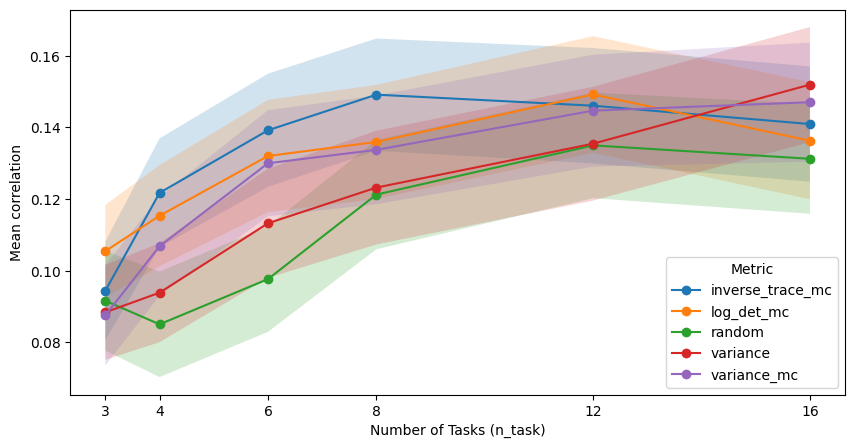

In [16]:
plt.figure(figsize=(10, 5))
for metric in summary_df['metric'].unique():
    subset = summary_df[summary_df['metric'] == metric]
    plt.plot(subset['n_task'], subset['mean_correlation'], marker='o', label=metric)
    plt.fill_between(subset['n_task'],
                     subset['mean_correlation'] - subset['sem_correlation'],
                     subset['mean_correlation'] + subset['sem_correlation'],
                     alpha=0.2) 

plt.xlabel("Number of Tasks (n_task)")
plt.xticks(battery_sizes)
plt.ylabel("Mean correlation")
plt.legend(title="Metric")
plt.show()